# AI for Safer Roads Innovation Challenge 2026  
## Speed Limit Misalignment Model

**Purpose of this notebook:** build a clear, reproducible, policy-ready model that helps road agencies identify where **posted speed limits may be misaligned with real-world road conditions**.

This notebook is designed for both technical reviewers and business / policy users. The code is reproducible, while each step explains the decision in plain language.

### Business problem
Road agencies need to know **which road segments should be reviewed first** because their posted speed limits may be too high for the surrounding land use, road function, operating speeds, and likely vulnerable-road-user exposure.

### Important framing
This is **not** a speeding-enforcement model. We are not trying to identify bad drivers. We are checking whether the **current speed limit itself** appears suitable for the road environment.

### Solution in one sentence
We combine Safe System speed guidance, road function, urban/rural land use, operating speeds, traffic exposure, and an interpretable AI/ML peer model to create a **Speed Safety Score**, **Priority Score**, **priority band**, and **geospatial outputs** that governments can use for review and intervention planning.

---


## 0. How this notebook aligns with the challenge requirements

The ADB challenge asks for a solution that can assess Safe System alignment, identify misaligned speed limits, produce policy-ready spatial outputs, and be scalable across countries. This notebook is structured around those requirements.

| Challenge requirement | How this notebook answers it |
|---|---|
| **Safe Speed Assessment** | Compares posted speed limits against Safe System reference speeds based on road class and land use. |
| **Risk Identification** | Flags roads where posted limits and operating speeds exceed the reference speed, especially in higher vulnerable-road-user environments. |
| **Policy-Ready Outputs** | Produces `PriorityScore`, `SpeedSafetyScore`, `PriorityBand`, recommendations, CSV, GeoJSON, and an interactive HTML map. |
| **Scalable and replicable across countries** | Uses the same standardized field schema and scoring workflow for Maharashtra and Thailand. |
| **Transparent and interpretable** | Shows the contribution of each component: posted-limit mismatch, operating-speed context, VRU proxy, traffic exposure, and peer-model gap. |
| **Methodologically robust** | Includes data validation, filtering audit, model diagnostics, sensitivity testing, and reproducibility notes. |

**Source references used in the narrative and methodology:**
- ADB AI for Safer Roads Innovation Challenge official page and criteria.
- AI for Safer Roads 2026 Data User Guide v1.0.
- Safe System / speed-management guidance from WHO, World Bank / GRSF, ITF/OECD, and iRAP.

---

## 1. Data sources and modelling philosophy

### Data provided
The model uses two GeoJSON files:

1. `ADB_Innovation_Maharashtra.geojson`
2. `ADB_Innovation_Thailand.geojson`

The Data User Guide explains that the road network comes from Overture/OpenStreetMap-based road sections and is enriched with TomTom-derived speed, probe, and traffic-exposure indicators. It also explains that the files are backend data for an online dashboard and that **many fields are not required**. The most important fields are generally those relating to **sample size and vehicle speeds**.

### Modelling philosophy
We use a **hybrid approach**:

1. **Rules grounded in Safe System thinking** for transparent, policy-aligned screening.
2. **Geospatial analytics** to preserve road-segment location and enable map-based review.
3. **AI/ML peer model** as a supporting signal to identify speed limits that look high compared with similar road contexts.

The model intentionally keeps the AI component small in the final score because the dataset does not include all engineering factors that usually determine a legally appropriate speed limit, such as median barriers, pedestrian crossings, school zones, markets, lane width, roadside activity, or access control.

---

## 2. Reproducibility checklist

To rerun this notebook from scratch:

1. Place the two GeoJSON files in the same folder as this notebook, or set the `SAFER_ROADS_DATA_DIR` environment variable to the folder containing the files.
2. Run all cells from top to bottom.
3. Outputs will be written to a folder called `safer_roads_submission_outputs`.

### Expected Python packages
- `pandas`
- `numpy`
- `geopandas`
- `shapely`
- `matplotlib`
- `scikit-learn`
- `folium`

The workflow uses a fixed random seed so the AI peer model and diagnostics are reproducible.



In [1]:
# ============================================================
# 2.1 Setup
# ============================================================

from pathlib import Path
import os
import glob
import json
import warnings
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint


warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

# Search for inputs in the current folder and /mnt/data.
# This makes the notebook easy to rerun locally or in a cloud notebook.
SEARCH_ROOTS = []
if os.environ.get("SAFER_ROADS_DATA_DIR"):
    SEARCH_ROOTS.append(Path(os.environ["SAFER_ROADS_DATA_DIR"]))
SEARCH_ROOTS.extend([Path.cwd(), Path("/mnt/data")])
SEARCH_ROOTS = list(dict.fromkeys([p.resolve() for p in SEARCH_ROOTS if p.exists()]))

OUTPUT_DIR = Path.cwd() / "safer_roads_submission_outputs"
if str(Path.cwd()) == "/":
    OUTPUT_DIR = Path("/mnt/data/safer_roads_submission_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Search roots:")
for root in SEARCH_ROOTS:
    print(" -", root)
print("\nOutputs will be saved to:", OUTPUT_DIR)

Search roots:
 - /content

Outputs will be saved to: /content/safer_roads_submission_outputs


In [3]:
# ============================================================
# 2.2 Locate input files
# ============================================================

def find_latest_file(patterns, roots=SEARCH_ROOTS):
    # Find the newest file matching any of the patterns across search roots.
    matches = []
    for root in roots:
        for pattern in patterns:
            matches.extend(root.glob(pattern))
    matches = [p for p in matches if p.is_file()]
    if not matches:
        raise FileNotFoundError(f"No file found for patterns: {patterns}. Check DATA_DIR or file names.")
    return sorted(matches, key=lambda p: p.stat().st_mtime)[-1]

maha_path = find_latest_file(["ADB_Innovation_Maharashtra*.geojson", "*Maharashtra*.geojson"])
thai_path = find_latest_file(["ADB_Innovation_Thailand*.geojson", "*Thailand*.geojson"])

print("Maharashtra file:", maha_path)
print("Thailand file:", thai_path)

Maharashtra file: /content/ADB_Innovation_Maharashtra.geojson
Thailand file: /content/ADB_Innovation_Thailand.geojson


## 3. Load the GeoJSON files

We load both datasets as GeoDataFrames so the geometry is preserved for mapping and GeoJSON export.

In [4]:
# ============================================================
# 3. Load data
# ============================================================

def load_country_geojson(path, country):
    gdf = gpd.read_file(path)
    gdf["Country"] = country
    return gdf

maha_raw = load_country_geojson(maha_path, "Maharashtra")
thai_raw = load_country_geojson(thai_path, "Thailand")

raw_summary = pd.DataFrame({
    "Country": ["Maharashtra", "Thailand", "Total"],
    "Raw rows": [len(maha_raw), len(thai_raw), len(maha_raw) + len(thai_raw)],
    "Raw columns": [maha_raw.shape[1], thai_raw.shape[1], None]
})
raw_summary

,Country,Raw rows,Raw columns
0,Maharashtra,14082,29.0
1,Thailand,55884,28.0
2,Total,69966,NaN


In [10]:
# Quick column audit: which fields appear in each file?
maha_cols = set(maha_raw.columns)
thai_cols = set(thai_raw.columns)

column_audit = pd.DataFrame({
    "Column": sorted(maha_cols.union(thai_cols)),
    "In Maharashtra": [c in maha_cols for c in sorted(maha_cols.union(thai_cols))],
    "In Thailand": [c in thai_cols for c in sorted(maha_cols.union(thai_cols))]
})
column_audit

,Column,In Maharashtra,In Thailand
0,AnalysisStatus,True,True
1,Country,True,True
2,DISSOLVE_ID,True,False
3,ExcludeFromSpeedSPI,True,False
4,F85thPercentileSpeed,True,True
5,ForAnalysis,False,True
6,InvPercentile,False,True
7,LandUse,True,True
8,MedianSpeed,True,True
9,NO_OF_Result_Segments,False,True


## 4. Field standardization: what was included, standardized, and excluded

The two files are broadly similar, but some columns use different names for the same concept. We standardize those columns so one workflow can run across both countries.

### Key standardization decisions
- `names_primary` and `english_ro` both represent the road name, so both become `RoadName`.
- `Sample_Size_Total` and `SampleSizeTotal` both represent total sample size, so both become `SampleSizeTotal` and later `SampleSizeUnified`.
- `DISSOLVE_ID` and `OvertureID` are source-specific identifiers, so we keep them as `SourceRoadID` but create our own stable `SegmentID` from `Country + OBJECTID`.
- The model uses `Shape_Length`, not `RoadLength`, because the Data User Guide says to ignore `RoadLength` and use shape length.

### Why not include every field?
We only keep fields that help answer the challenge problem: is the posted limit appropriate for the road environment? Fields marked “ignore,” dashboard-only fields, country-only administrative fields, or duplicate raw columns are excluded from scoring.

In [11]:
# ============================================================
# 4.1 Included / standardized fields dictionary
# ============================================================

included_fields = pd.DataFrame([
    ["Country", "Created", "Source country / area", "Needed for country-level summaries and country-specific peer models."],
    ["SegmentID", "Created from Country + OBJECTID", "Stable model segment ID", "Makes IDs unique after combining countries."],
    ["SourceRoadID", "DISSOLVE_ID / OvertureID", "Original source road ID", "Kept for traceability to source data."],
    ["OBJECTID", "OBJECTID", "GIS-created unique ID", "Useful for tracing a result back to the original file."],
    ["RoadName", "names_primary / english_ro", "Road name", "Useful for business users, maps, and top-priority lists."],
    ["RoadClass", "RoadClass", "Motorway / trunk / primary / secondary", "Core model field. Reference speed depends on road function."],
    ["LandUse", "LandUse", "Urban / rural", "Core model field. Reference speed and VRU exposure differ by land use."],
    ["SpeedLimit", "SpeedLimit", "Posted speed limit", "Main field being assessed for possible misalignment."],
    ["MedianSpeed", "MedianSpeed", "50th percentile operating speed", "Operating-speed context; helps understand real-world speeds."],
    ["F85thPercentileSpeed", "F85thPercentileSpeed", "85th percentile operating speed", "Key operating-speed indicator; used to check whether the environment is operating above safe reference levels."],
    ["PercentOverLimit", "PercentOverLimit", "Estimated share over posted limit", "Used as context, not as the main scoring rule, to avoid becoming a driver-enforcement model."],
    ["WeightedSample", "WeightedSample", "Traffic exposure weighted by road length", "Prioritizes review where more travel occurs."],
    ["SampleSizeUnified", "Sample_Size_Total / SampleSizeTotal / SampleSize_avg", "Unified traffic sample size", "Confidence/context field for model diagnostics and peer model features."],
    ["RankedPercentile", "RankedPercentile", "Road's share/position in traffic exposure", "Converted into TrafficExposureScore for prioritization."],
    ["StreetImageLink", "StreetImageLink", "Lat/lon for street-level validation", "Useful for field validation and future image review, but not scored directly in Phase 1."],
    ["Shape_Length", "Shape_Length", "Geometric segment length", "Used for length summaries and geospatial outputs."],
    ["geometry", "geometry", "Road segment geometry", "Required for GeoJSON export and interactive map."],
    ["AnalysisStatus", "AnalysisStatus", "Internal validation flag", "Used to filter to records marked valid."],
], columns=["Standardized field", "Original field/s", "Plain-English meaning", "Why included"])

included_fields

,Standardized field,Original field/s,Plain-English meaning,Why included
0,Country,Created,Source country / area,Needed for country-level summaries and country-specific peer models.
1,SegmentID,Created from Country + OBJECTID,Stable model segment ID,Makes IDs unique after combining countries.
2,SourceRoadID,DISSOLVE_ID / OvertureID,Original source road ID,Kept for traceability to source data.
3,OBJECTID,OBJECTID,GIS-created unique ID,Useful for tracing a result back to the original file.
4,RoadName,names_primary / english_ro,Road name,"Useful for business users, maps, and top-priority lists."
5,RoadClass,RoadClass,Motorway / trunk / primary / secondary,Core model field. Reference speed depends on road function.
6,LandUse,LandUse,Urban / rural,Core model field. Reference speed and VRU exposure differ by land use.
7,SpeedLimit,SpeedLimit,Posted speed limit,Main field being assessed for possible misalignment.
8,MedianSpeed,MedianSpeed,50th percentile operating speed,Operating-speed context; helps understand real-world speeds.
9,F85thPercentileSpeed,F85thPercentileSpeed,85th percentile operating speed,Key operating-speed indicator; used to check whether the environment is oper...


In [12]:
# ============================================================
# 4.2 Excluded fields dictionary
# ============================================================

excluded_fields = pd.DataFrame([
    ["RoadLength", "Data guide says ignore and use Shape_Length instead."],
    ["Percent_", "Data guide says ignore."],
    ["ForAnalysis", "Data guide says ignore; AnalysisStatus is used for validation filtering instead."],
    ["ProvinceID", "Thailand-only administrative field; guide says not useful for this analysis."],
    ["SpeedLimitFloor", "Data guide says ignore."],
    ["NO_OF_Result_Segments", "Data guide says ignore."],
    ["InvPercentile", "Dashboard filtering field only; not needed for model scoring."],
    ["PercentileBand / percentileBand", "Dashboard category; numeric RankedPercentile is better for scoring."],
    ["Percentile", "Raw percentile retained only for audit if needed; RankedPercentile is clearer for traffic exposure scoring."],
    ["NumberOverLimit", "Not used in final score to avoid making the model a speeding-enforcement model; PercentOverLimit and operating speeds are used as context."],
    ["DISSOLVE_ID", "Maharashtra-only source ID; standardized into SourceRoadID."],
    ["OvertureID", "Thailand source ID; standardized into SourceRoadID."],
    ["names_primary", "Maharashtra road-name field; standardized into RoadName."],
    ["english_ro", "Thailand road-name field; standardized into RoadName."],
    ["Sample_Size_Total", "Maharashtra sample-size field; standardized into SampleSizeUnified."],
    ["SampleSizeTotal", "Thailand sample-size field; standardized into SampleSizeUnified."],
    ["class", "Raw Overture/source classification; RoadClass is the cleaner modelling field."],
    ["subtype", "Road subtype label, not needed for the score with available Phase 1 fields."],
    ["UrbanPC", "Maharashtra-only urban percentage; LandUse is used consistently across both countries."],
    ["Pass", "Maharashtra-specific flag; AnalysisStatus is used consistently."],
    ["ExcludeFromSpeedSPI", "Maharashtra-specific exclusion field; AnalysisStatus is used consistently."],
], columns=["Excluded / not directly scored field", "Reason"])

excluded_fields

,Excluded / not directly scored field,Reason
0,RoadLength,Data guide says ignore and use Shape_Length instead.
1,Percent_,Data guide says ignore.
2,ForAnalysis,Data guide says ignore; AnalysisStatus is used for validation filtering inst...
3,ProvinceID,Thailand-only administrative field; guide says not useful for this analysis.
4,SpeedLimitFloor,Data guide says ignore.
5,NO_OF_Result_Segments,Data guide says ignore.
6,InvPercentile,Dashboard filtering field only; not needed for model scoring.
7,PercentileBand / percentileBand,Dashboard category; numeric RankedPercentile is better for scoring.
8,Percentile,Raw percentile retained only for audit if needed; RankedPercentile is cleare...
9,NumberOverLimit,Not used in final score to avoid making the model a speeding-enforcement mod...


In [13]:
# ============================================================
# 4.3 Harmonize columns into one common schema
# ============================================================

STANDARD_RENAME = {
    "names_primary": "RoadName",
    "english_ro": "RoadName",
    "Sample_Size_Total": "SampleSizeTotal",
    "percentileBand": "PercentileBand",
    "PercentileBand": "PercentileBand",
}

KEEP_COLUMNS = [
    "Country", "SegmentID", "SourceRoadID", "OBJECTID", "RoadName", "RoadClass", "LandUse",
    "SpeedLimit", "MedianSpeed", "F85thPercentileSpeed", "PercentOverLimit", "NumberOverLimit",
    "WeightedSample", "SampleSizeUnified", "RankedPercentile", "StreetImageLink",
    "Shape_Length", "AnalysisStatus", "geometry"
]

NUMERIC_COLUMNS = [
    "SpeedLimit", "MedianSpeed", "F85thPercentileSpeed", "PercentOverLimit", "NumberOverLimit",
    "WeightedSample", "SampleSizeUnified", "RankedPercentile", "Shape_Length"
]


def harmonize(gdf):
    gdf = gdf.copy()
    gdf = gdf.rename(columns={k: v for k, v in STANDARD_RENAME.items() if k in gdf.columns})

    if "RoadName" not in gdf.columns:
        gdf["RoadName"] = np.nan

    if "SampleSizeTotal" not in gdf.columns:
        gdf["SampleSizeTotal"] = np.nan

    if "SampleSize_avg" in gdf.columns:
        gdf["SampleSizeUnified"] = gdf["SampleSizeTotal"].fillna(gdf["SampleSize_avg"])
    else:
        gdf["SampleSizeUnified"] = gdf["SampleSizeTotal"]

    if "DISSOLVE_ID" in gdf.columns:
        gdf["SourceRoadID"] = gdf["DISSOLVE_ID"].astype(str)
    elif "OvertureID" in gdf.columns:
        gdf["SourceRoadID"] = gdf["OvertureID"].astype(str)
    else:
        gdf["SourceRoadID"] = gdf["OBJECTID"].astype(str)

    gdf["SegmentID"] = gdf["Country"].astype(str) + "_" + gdf["OBJECTID"].astype(str)

    for c in KEEP_COLUMNS:
        if c not in gdf.columns:
            gdf[c] = np.nan

    return gdf[KEEP_COLUMNS]

maha = harmonize(maha_raw)
thai = harmonize(thai_raw)

combined = pd.concat([maha, thai], ignore_index=True)
gdf = gpd.GeoDataFrame(combined, geometry="geometry", crs=maha_raw.crs or thai_raw.crs)

for col in NUMERIC_COLUMNS:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

gdf["RoadClass"] = gdf["RoadClass"].astype(str).str.lower().str.strip()
gdf["LandUse"] = gdf["LandUse"].astype(str).str.upper().str.strip()
gdf["RoadName"] = gdf["RoadName"].replace({"None": np.nan, "nan": np.nan, "": np.nan})

print("Combined standardized shape:", gdf.shape)
gdf.head(3)

Combined standardized shape: (69966, 19)


,Country,SegmentID,SourceRoadID,OBJECTID,RoadName,RoadClass,LandUse,SpeedLimit,MedianSpeed,F85thPercentileSpeed,PercentOverLimit,NumberOverLimit,WeightedSample,SampleSizeUnified,RankedPercentile,StreetImageLink,Shape_Length,AnalysisStatus,geometry
0,Maharashtra,Maharashtra_1,SE/4183,1,None,secondary,RURAL,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,0.000249,"73.5544591,16.2774648,73.53445,16.2401913",5872.278972,Valid,"LINESTRING (73.55446 16.27746, 73.5543 16.27709, 73.55406 16.27677, 73.55379..."
1,Maharashtra,Maharashtra_2,SE/6376,2,None,secondary,RURAL,55.0,18.0,18.0,0.0,0.0,2.950476,1.0,0.000499,"73.9651122,21.0463691,73.9910297,21.0647687",5900.951225,Valid,"LINESTRING (73.96511 21.04637, 73.96506 21.04779, 73.96506 21.048, 73.96507 ..."
2,Maharashtra,Maharashtra_3,SE/8617,3,None,secondary,RURAL,NaN,23.5,27.0,0.0,0.0,3.496819,2.0,0.000748,"74.9005386,19.0351416,74.8847951,19.020001",3496.819447,Valid,"LINESTRING (74.90054 19.03514, 74.90002 19.03427, 74.89958 19.03385, 74.8992..."


## 5. Data-quality filtering

We keep only records that can support a defensible speed-limit review. This is important for methodological robustness because the final score should not be driven by missing or invalid inputs.

A segment is included if:

1. `AnalysisStatus = Valid`
2. `SpeedLimit > 0`
3. `F85thPercentileSpeed > 0`
4. `RoadClass` is one of: motorway, trunk, primary, secondary
5. `LandUse` is urban or rural

The funnel below shows how many rows remain after each validation step.

In [14]:
# ============================================================
# 5. Filtering funnel
# ============================================================

def count_by_country(df, step):
    counts = df["Country"].value_counts().to_dict()
    return {
        "Step": step,
        "Maharashtra": counts.get("Maharashtra", 0),
        "Thailand": counts.get("Thailand", 0),
        "Total": len(df)
    }

filter_audit = []
filter_audit.append(count_by_country(gdf, "Raw input rows"))

valid = gdf.copy()
filter_steps = [
    ("AnalysisStatus = Valid", valid["AnalysisStatus"].eq("Valid")),
    ("Has positive posted speed limit", valid["SpeedLimit"].gt(0)),
    ("Has positive 85th percentile speed", valid["F85thPercentileSpeed"].gt(0)),
    ("Has recognized road class", valid["RoadClass"].isin(["motorway", "trunk", "primary", "secondary"])),
    ("Has recognized land use", valid["LandUse"].isin(["URBAN", "RURAL"])),
]

for step_name, mask in filter_steps:
    valid = valid.loc[mask.loc[valid.index]].copy()
    filter_audit.append(count_by_country(valid, step_name))

filter_funnel = pd.DataFrame(filter_audit)
filter_funnel

,Step,Maharashtra,Thailand,Total
0,Raw input rows,14082,55884,69966
1,AnalysisStatus = Valid,4010,11544,15554
2,Has positive posted speed limit,3577,11134,14711
3,Has positive 85th percentile speed,3577,11134,14711
4,Has recognized road class,3577,11134,14711
5,Has recognized land use,3577,11134,14711


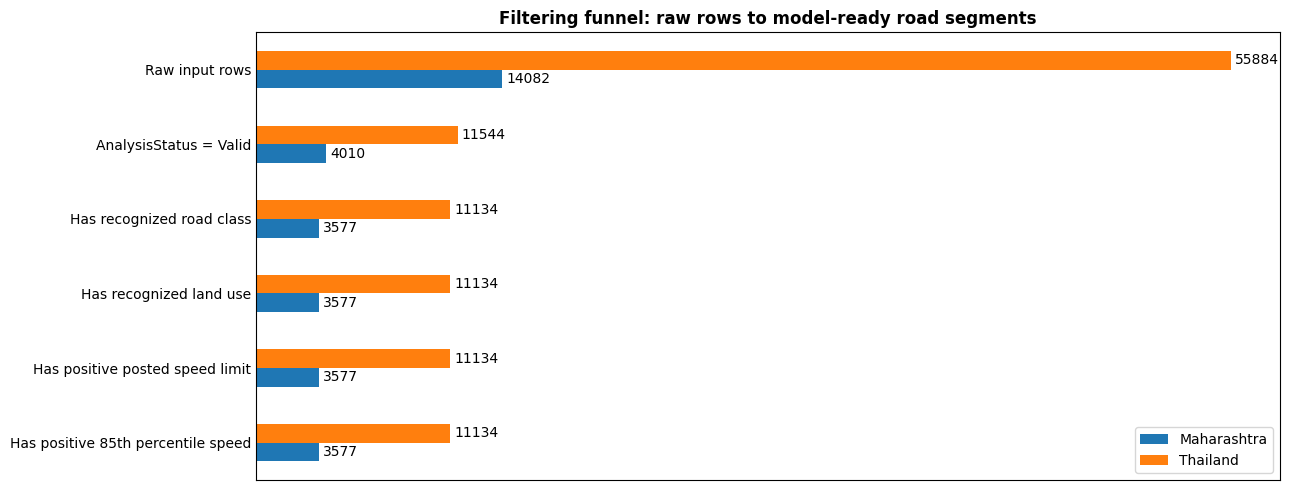

In [15]:
# Chart: filtering funnel by country
# Calculate total to sort the y-axis (categories) descending by value
plot_df = filter_funnel.set_index("Step")[["Maharashtra", "Thailand"]]
plot_df["Total"] = plot_df["Maharashtra"] + plot_df["Thailand"]
# Sort ascending so that the plot (plotted from bottom to top) shows largest values at the top
plot_df = plot_df.sort_values("Total", ascending=True).drop(columns="Total")

ax = plot_df.plot(kind="barh", figsize=(13, 5))
ax.set_title("Filtering funnel: raw rows to model-ready road segments", fontweight="bold")
ax.set_xlabel("") # Removed x-axis title
ax.set_ylabel("") # Added y-axis title back
ax.set_xticks([]) # Remove numerical x-axis labels
# Ensure y-axis labels (Step names) are shown
ax.tick_params(axis='y', which='both', length=0)

# Add value labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_filtering_funnel.png", dpi=160, bbox_inches="tight")
plt.show()

In [16]:
# Missingness check after filtering
missingness = (
    valid[["RoadClass", "LandUse", "SpeedLimit", "MedianSpeed", "F85thPercentileSpeed", "WeightedSample", "SampleSizeUnified", "RankedPercentile", "Shape_Length"]]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)
missingness.columns = ["Field", "Missing % after filtering"]
missingness

,Field,Missing % after filtering
0,RoadClass,0.0
1,LandUse,0.0
2,SpeedLimit,0.0
3,MedianSpeed,0.0
4,F85thPercentileSpeed,0.0
5,WeightedSample,0.0
6,SampleSizeUnified,0.0
7,RankedPercentile,0.0
8,Shape_Length,0.0


## 6. Safe System reference speed table

The reference speed is a **screening benchmark**, not a final legal speed-limit recommendation.

The directly published Safe System anchor values commonly used in speed-management guidance are around:

- **30 km/h** where pedestrians, cyclists, motorcycles, or other vulnerable users mix with vehicles.
- **50 km/h** where side-impact / intersection risk is important.
- **70 km/h** where head-on crashes are possible and median protection is unknown or absent.
- **100 km/h** for access-controlled, protected motorway-type environments.

Because the Phase 1 dataset does not include detailed engineering features such as median barriers, school zones, crossings, roadside markets, lane width, or access control, we translate the guidance into a practical **road-class + land-use screening table**.

The model is intentionally conservative for urban and secondary roads because they are more likely to have vulnerable-road-user exposure.

In [17]:
# ============================================================
# 6. Reference speed table
# ============================================================

reference_speed_table = pd.DataFrame([
    ["URBAN", "secondary", 30, "Likely higher pedestrian/cyclist/two-wheeler exposure and roadside activity."],
    ["URBAN", "primary", 50, "Urban arterial context; side-impact and intersection risk may be present."],
    ["URBAN", "trunk", 50, "Higher-function urban road, but still in an urban exposure environment unless access control is confirmed."],
    ["URBAN", "motorway", 80, "Assumes stronger separation; field validation needed to confirm controlled access."],
    ["RURAL", "secondary", 60, "Mixed traffic and roadside access may still be present."],
    ["RURAL", "primary", 70, "Possible head-on and access risk where physical separation is unknown."],
    ["RURAL", "trunk", 80, "Higher-function rural road; verify protection before allowing higher limits."],
    ["RURAL", "motorway", 100, "Assumes limited access and physical protection."],
], columns=["LandUse", "RoadClass", "SafeReferenceLimit_kmh", "Rationale"])

reference_speed_table

,LandUse,RoadClass,SafeReferenceLimit_kmh,Rationale
0,URBAN,secondary,30,Likely higher pedestrian/cyclist/two-wheeler exposure and roadside activity.
1,URBAN,primary,50,Urban arterial context; side-impact and intersection risk may be present.
2,URBAN,trunk,50,"Higher-function urban road, but still in an urban exposure environment unles..."
3,URBAN,motorway,80,Assumes stronger separation; field validation needed to confirm controlled a...
4,RURAL,secondary,60,Mixed traffic and roadside access may still be present.
5,RURAL,primary,70,Possible head-on and access risk where physical separation is unknown.
6,RURAL,trunk,80,Higher-function rural road; verify protection before allowing higher limits.
7,RURAL,motorway,100,Assumes limited access and physical protection.


In [18]:
# Apply Safe System reference speeds
ref_lookup = reference_speed_table.set_index(["LandUse", "RoadClass"])["SafeReferenceLimit_kmh"].to_dict()
valid["SafeReferenceLimit_kmh"] = valid.set_index(["LandUse", "RoadClass"]).index.map(ref_lookup)

valid[["Country", "SegmentID", "RoadName", "RoadClass", "LandUse", "SpeedLimit", "SafeReferenceLimit_kmh"]].head()

,Country,SegmentID,RoadName,RoadClass,LandUse,SpeedLimit,SafeReferenceLimit_kmh
1,Maharashtra,Maharashtra_2,None,secondary,RURAL,55.0,60
3,Maharashtra,Maharashtra_4,उमरी रोड,secondary,RURAL,55.0,60
4,Maharashtra,Maharashtra_5,None,secondary,RURAL,55.0,60
5,Maharashtra,Maharashtra_6,None,secondary,RURAL,45.0,60
8,Maharashtra,Maharashtra_9,None,secondary,RURAL,55.0,60


## 7. Feature engineering: translating the problem into measurable signals

Each segment receives five interpretable signals.

| Signal | Plain-language meaning | Why it matters |
|---|---|---|
| `PostedExcess_kmh` | How far the posted speed limit is above the Safe System reference speed | Main measure of speed-limit misalignment. |
| `OperatingExcess_kmh` | Whether typical high-end operating speeds are also above the reference speed | Adds real-world context without turning the model into speeding enforcement. |
| `VRUExposureProxy` | Proxy for vulnerable-road-user exposure from land use and road class | Helps prioritize urban and lower-class roads where people outside cars are more exposed. |
| `TrafficExposureScore` | Whether the road carries more travel exposure | Helps government prioritize locations with larger potential public-safety impact. |
| `PeerGap_kmh` | How high the posted limit looks compared with similar peer roads | AI support signal; kept small for transparency. |

In [19]:
# ============================================================
# 7. Feature engineering
# ============================================================

# 1) Posted-limit mismatch: Is the legal limit itself higher than the Safe System reference?
valid["PostedExcess_kmh"] = (valid["SpeedLimit"] - valid["SafeReferenceLimit_kmh"]).clip(lower=0)

# 2) Operating-speed context: do observed operating speeds also sit above the reference?
# We cap by SpeedLimit so we do not simply score illegal speeding as a speed-limit problem.
valid["OperatingExcess_kmh"] = (
    np.minimum(valid["F85thPercentileSpeed"], valid["SpeedLimit"]) - valid["SafeReferenceLimit_kmh"]
).clip(lower=0)

# 3) Difference between 85th percentile speed and the posted limit, kept for interpretation.
valid["F85MinusLimit_kmh"] = valid["F85thPercentileSpeed"] - valid["SpeedLimit"]

# 4) VRU exposure proxy based only on fields available in Phase 1.
# Urban roads start higher; secondary and primary roads are treated as more likely to have mixing/access activity.
def vru_proxy(row):
    base = 0.55 if row["LandUse"] == "URBAN" else 0.20
    class_add = {"secondary": 0.25, "primary": 0.18, "trunk": 0.08, "motorway": 0.00}.get(row["RoadClass"], 0.10)
    return min(1.0, base + class_add)

valid["VRUExposureProxy"] = valid.apply(vru_proxy, axis=1)

# 5) Traffic exposure score: prioritize high-exposure roads using RankedPercentile where available.
valid["TrafficExposureScore"] = (valid["RankedPercentile"] / 100).clip(0, 1).fillna(0)

# 6) Sample confidence: used for interpretation and diagnostics, not to hide risk.
valid["SampleConfidence"] = np.log1p(valid["SampleSizeUnified"].fillna(0))
max_conf = valid["SampleConfidence"].max() or 1
valid["SampleConfidence"] = (valid["SampleConfidence"] / max_conf).clip(0, 1)

feature_preview = valid[[
    "Country", "SegmentID", "RoadName", "RoadClass", "LandUse", "SpeedLimit", "SafeReferenceLimit_kmh",
    "PostedExcess_kmh", "F85thPercentileSpeed", "OperatingExcess_kmh", "VRUExposureProxy", "TrafficExposureScore", "SampleConfidence"
]].head(10)
feature_preview

,Country,SegmentID,RoadName,RoadClass,LandUse,SpeedLimit,SafeReferenceLimit_kmh,PostedExcess_kmh,F85thPercentileSpeed,OperatingExcess_kmh,VRUExposureProxy,TrafficExposureScore,SampleConfidence
1,Maharashtra,Maharashtra_2,None,secondary,RURAL,55.0,60,0.0,18.000000,0.0,0.45,0.000005,0.037838
3,Maharashtra,Maharashtra_4,उमरी रोड,secondary,RURAL,55.0,60,0.0,18.000000,0.0,0.45,0.000010,0.087857
4,Maharashtra,Maharashtra_5,None,secondary,RURAL,55.0,60,0.0,13.333333,0.0,0.45,0.000012,0.106225
5,Maharashtra,Maharashtra_6,None,secondary,RURAL,45.0,60,0.0,62.500000,0.0,0.45,0.000015,0.166197
8,Maharashtra,Maharashtra_9,None,secondary,RURAL,55.0,60,0.0,29.500000,0.0,0.45,0.000022,0.192500
9,Maharashtra,Maharashtra_10,None,secondary,RURAL,55.0,60,0.0,35.500000,0.0,0.45,0.000025,0.125695
10,Maharashtra,Maharashtra_11,None,secondary,RURAL,55.0,60,0.0,43.000000,0.0,0.45,0.000027,0.119944
12,Maharashtra,Maharashtra_13,None,secondary,RURAL,55.0,60,0.0,42.000000,0.0,0.45,0.000032,0.119944
13,Maharashtra,Maharashtra_14,None,secondary,RURAL,55.0,60,0.0,29.333333,0.0,0.45,0.000035,0.177856
14,Maharashtra,Maharashtra_15,None,secondary,RURAL,55.0,60,0.0,48.500000,0.0,0.45,0.000037,0.241873


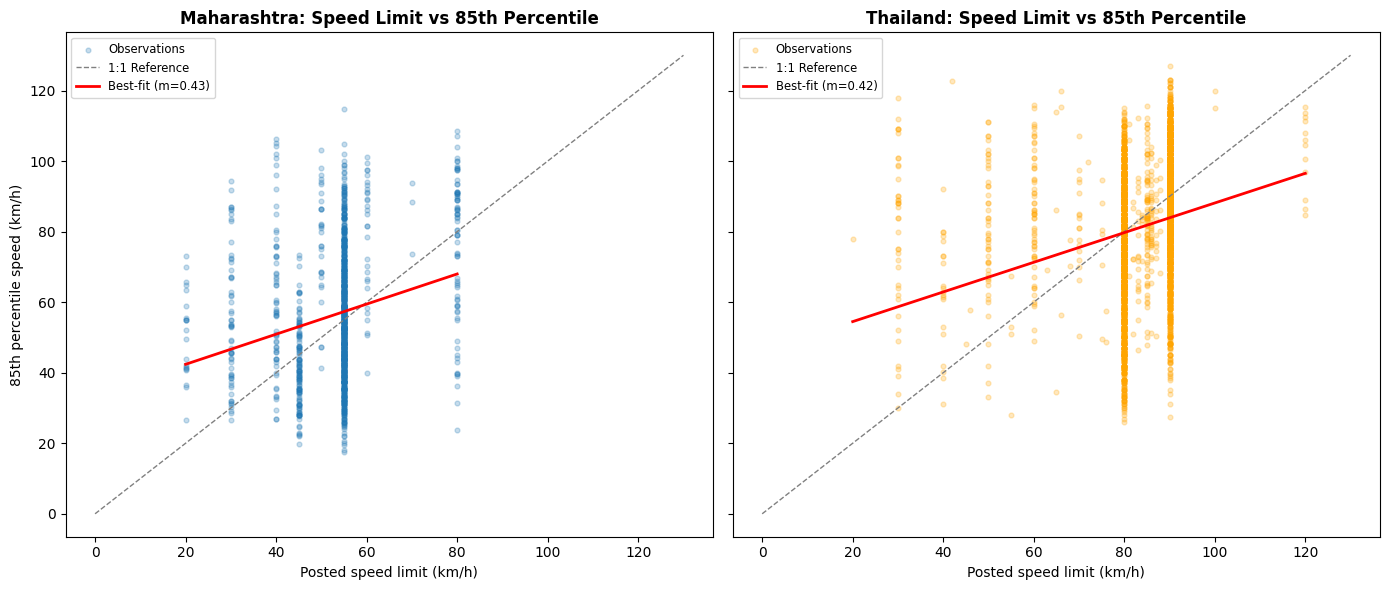

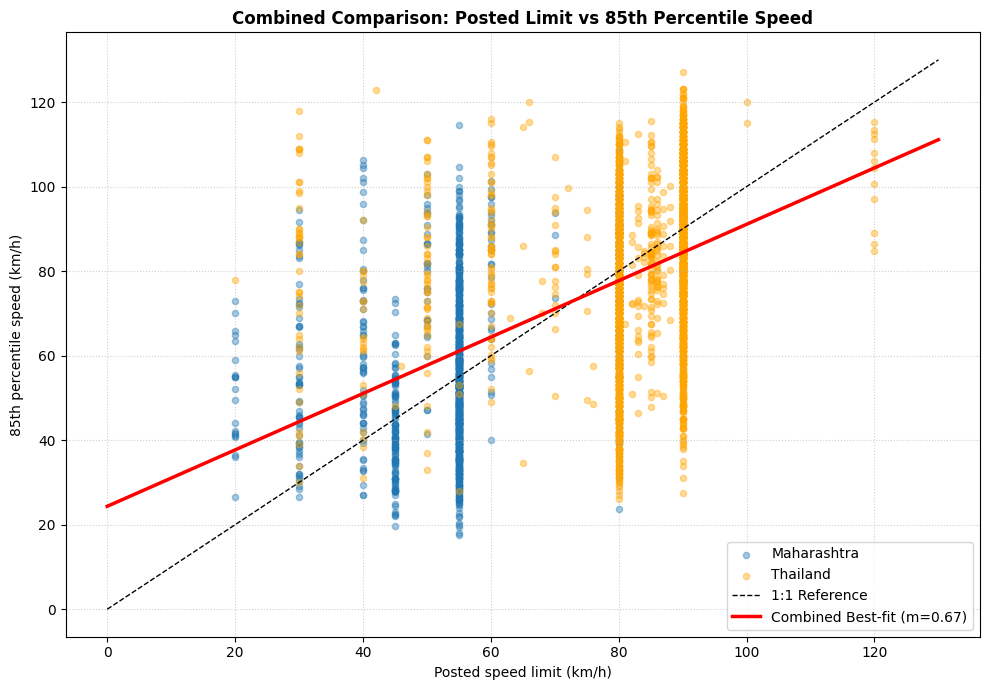

In [20]:
# Speed limit vs 85th percentile speed
# Chart 1: Faceted Scatter with Best-Fit Lines
sample_scatter = valid.sample(min(5000, len(valid)), random_state=RANDOM_STATE)
countries = sorted(sample_scatter['Country'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, country in enumerate(countries):
    sub = sample_scatter[sample_scatter['Country'] == country]
    ax = axes[i]

    # Explicit color: Thailand = orange, Maharashtra = blue
    obs_color = 'orange' if country == 'Thailand' else 'tab:blue'

    # Scatter points
    ax.scatter(sub['SpeedLimit'], sub['F85thPercentileSpeed'], alpha=0.25, s=12, label='Observations', color=obs_color)

    # 1:1 Reference line
    ax.plot([0, 130], [0, 130], color='gray', linestyle='--', linewidth=1, label='1:1 Reference')

    # Best-fit line (linear regression)
    if len(sub) > 1:
        m, b = np.polyfit(sub['SpeedLimit'], sub['F85thPercentileSpeed'], 1)
        x_range = np.array([sub['SpeedLimit'].min(), sub['SpeedLimit'].max()])
        ax.plot(x_range, m*x_range + b, color='red', linewidth=2, label=f'Best-fit (m={m:.2f})')

    ax.set_title(f"{country}: Speed Limit vs 85th Percentile", fontweight='bold')
    ax.set_xlabel("Posted speed limit (km/h)")
    if i == 0: ax.set_ylabel("85th percentile speed (km/h)")
    ax.legend(fontsize='small')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02a_speedlimit_vs_f85_by_country.png", dpi=160)
plt.show()

# Chart 2: Combined Scatter Plot (Thailand = Orange, Maharashtra = Blue)
plt.figure(figsize=(10, 7))
colors = {'Maharashtra': 'tab:blue', 'Thailand': 'orange'}

for country in countries:
    sub = sample_scatter[sample_scatter['Country'] == country]
    plt.scatter(
        sub['SpeedLimit'],
        sub['F85thPercentileSpeed'],
        alpha=0.4,
        s=20,
        label=country,
        color=colors.get(country, 'gray')
    )

# 1:1 Reference line
plt.plot([0, 130], [0, 130], color='black', linestyle='--', linewidth=1, label='1:1 Reference')

# Best-fit line for the combined dataset
if len(sample_scatter) > 1:
    m_comb, b_comb = np.polyfit(sample_scatter['SpeedLimit'], sample_scatter['F85thPercentileSpeed'], 1)
    x_range_comb = np.array([0, 130])
    plt.plot(x_range_comb, m_comb*x_range_comb + b_comb, color='red', linewidth=2.5, label=f'Combined Best-fit (m={m_comb:.2f})')

plt.title("Combined Comparison: Posted Limit vs 85th Percentile Speed", fontweight='bold')
plt.xlabel("Posted speed limit (km/h)")
plt.ylabel("85th percentile speed (km/h)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02b_speedlimit_vs_f85_combined.png", dpi=160)
plt.show()

# Chart 1: Maharashtra — Speed Limit vs 85th Percentile Speed

This chart compares the posted speed limit on Maharashtra road segments with the 85th percentile speed, which is a way of showing the speed that most drivers are staying under. In simple terms, it gives us an idea of the typical higher-end operating speed on the road.

The black dashed line is the 1:1 reference line. If a point sits exactly on this line, it means the 85th percentile speed is equal to the posted speed limit. For example, if the posted limit is 60 km/h and the 85th percentile speed is also 60 km/h, the point would fall on this line.

The blue points show the actual road observations in Maharashtra. One thing we can see is that there is a lot of spread at the same posted speed limit. For example, many roads with similar posted limits still have very different 85th percentile speeds. This tells us that the posted limit alone does not fully explain how fast drivers actually travel. Road design, roadside activity, access points, enforcement, and road condition may also affect behavior.

The red best-fit line slopes upward, which means that as posted speed limits increase, operating speeds also tend to increase. However, the slope is only around 0.43, meaning the increase is not one-to-one. So if the posted limit increases by 10 km/h, the typical high-end operating speed does not increase by the full 10 km/h. It increases, but more slowly.

A useful observation is that at lower and mid-range posted limits, some points are above the 1:1 line. This means that on some lower-speed roads, drivers are traveling faster than the posted limit. At higher posted limits, many points are closer to or below the reference line, which may suggest better compliance or that the road environment naturally limits speeds.


# Chart 2: Thailand — Speed Limit vs 85th Percentile Speed

This chart shows the same comparison, but for Thailand.

The orange points are Thailand road observations. Like Maharashtra, the points are quite spread out. This means that even roads with the same posted speed limit can have very different actual operating speeds.

One very noticeable pattern is that many observations are concentrated around 80 km/h. This suggests that 80 km/h is a common posted speed limit in the Thailand dataset. But even within that same 80 km/h posted limit, the 85th percentile speeds vary widely. Some are much lower, while others are much higher.

The red best-fit line again slopes upward, with a slope of about 0.42. This is very close to Maharashtra’s slope. That means Thailand also shows the same general pattern: higher posted speed limits are linked with higher operating speeds, but not in a one-to-one way.

At lower and mid-range posted limits, several points appear above the 1:1 line, which suggests possible speeding or posted limits that do not match actual driving behavior. At the higher posted limits, many points are closer to or below the reference line, though there are still some high-speed observations.


# Chart 3: Combined Comparison — Maharashtra and Thailand

The third chart combines both countries in one view. The blue points represent Maharashtra, while the orange points represent Thailand.

This chart is useful because it lets us compare whether the two places show very different patterns. Overall, the two clouds overlap quite a lot. That means the relationship between posted limits and 85th percentile speeds is broadly similar in both datasets. There is no obvious pattern where one country is completely separate from the other.

The red combined best-fit line has a stronger slope, around 0.67, compared with the separate country-level charts. This means that when we look at both countries together, the overall relationship between posted limits and operating speeds becomes clearer. In general, higher posted limits are associated with higher operating speeds.

However, the red line still does not perfectly match the black 1:1 line. This means drivers do not simply follow posted limits exactly. Actual operating speed is influenced by other road conditions too.

At low to mid posted limits, many points are above the black reference line. This suggests that in lower-speed environments, actual high-end speeds can exceed the posted limit. This matters for safety because these areas may include more access points, pedestrians, cyclists, two-wheelers, or roadside activity.

At higher posted limits, especially around 80 to 120 km/h, many points are closer to or below the 1:1 line. This may mean that drivers are more aligned with posted limits in higher-speed corridors, or that the physical road environment naturally controls speed.

# **Key takeaways**

* As posted limits increase, typical operating speeds also increase, but by a smaller margin; drivers do not fully “use” each additional km/h of posted limit, which is why the best-fit line lies below the 1:1 black reference line at higher limits.

* At low to mid limits (roughly 20-60 km/h), many points are above the 1:1 line, suggesting drivers often exceed the posted limit in these zones, while at higher limits (80-120 km/h), points tend to fall closer to or below the reference line, implying relatively better compliance or natural speed constraints.

* The overlapping clouds of blue (Maharashtra) and orange (Thailand) indicate broadly similar operating-speed behavior between the two regions, with substantial variability at each posted limit but no stark systematic difference visible in this combined view.

---




## 8. AI/ML peer model: a supporting signal, not the main decision rule

The peer model estimates the speed limit typically associated with comparable road segments using available context fields.

### Why include this?
A purely rule-based score may miss unusual cases. The peer model adds a data-driven check: “Compared with similar roads in the same country, does this posted limit look high?”

### Why keep it small?
Posted speed limits are partly shaped by local policy and engineering details not fully included in the Phase 1 files. Therefore, the peer model is used as a **5% supporting signal**, while the main score remains transparent and Safe System-aligned.

In [21]:
# ============================================================
# 8. Country-specific Random Forest peer model
# ============================================================
import time
PEER_FEATURES = [
    "RoadClass", "LandUse", "MedianSpeed", "F85thPercentileSpeed", "WeightedSample",
    "SampleSizeUnified", "RankedPercentile", "Shape_Length"
]
CATEGORICAL_FEATURES = ["RoadClass", "LandUse"]
NUMERIC_FEATURES = [c for c in PEER_FEATURES if c not in CATEGORICAL_FEATURES]

# --- Tuning config (knobs) ---
N_ITER = 20
MAX_CV_FOLDS = 4
MIN_ROWS_FOR_TUNING = 60
MIN_ROWS_FOR_MODEL = 12
SCORING = "neg_mean_absolute_error"
SEARCH_VERBOSE = 1          # 1 = periodic "[Parallel] Done X/Y" (alive signal); 2 = per-fit time; 0 = silent

# Search space — trimmed for speed. max_depth=None dropped (fully-grown trees = most of the cost).
PARAM_DISTRIBUTIONS = {
    "model__n_estimators":      randint(150, 350),
    "model__max_depth":         [8, 12, 16, 24],
    "model__min_samples_leaf":  randint(5, 40),
    "model__min_samples_split": randint(2, 20),
    "model__max_features":      ["sqrt", "log2", 0.5, 0.75, 1.0],
    "model__max_samples":       [0.7, 0.85, 1.0],
}

DEFAULT_PARAMS = dict(n_estimators=250, min_samples_leaf=25,
                      random_state=RANDOM_STATE, n_jobs=-1)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(rf):
    preprocess = ColumnTransformer([
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), CATEGORICAL_FEATURES),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), NUMERIC_FEATURES)
    ])
    return Pipeline([("preprocess", preprocess), ("model", rf)])


# --- Precompute order & ETA scope (largest country first -> worst case surfaces immediately,
#     and if RAM is going to blow it blows in minute 1, not minute 15) ---
_sizes  = valid.dropna(subset=["SpeedLimit"]).groupby("Country").size()
_order  = _sizes.sort_values(ascending=False)
_groups = valid.groupby("Country").groups
_predicted_tunable_rows = int(_sizes[(_sizes * 0.75) >= MIN_ROWS_FOR_TUNING].sum())

print(f"Countries total: {len(_order)} | predicted-tuned: {(( _sizes*0.75) >= MIN_ROWS_FOR_TUNING).sum()} "
      f"| tunable rows: {_predicted_tunable_rows} | biggest: {_order.head(3).to_dict()}\n")

peer_metrics = []
peer_best_params = {}
valid["PeerPredictedLimit_kmh"] = np.nan

rows_done_tunable = 0
tuning_time_done  = 0.0
t_loop_start = time.perf_counter()

for country in _order.index:
    sub = valid.loc[_groups[country]].dropna(subset=["SpeedLimit"]).copy()
    X, y = sub[PEER_FEATURES], sub["SpeedLimit"]
    t0 = time.perf_counter()
    n_folds = 0

    if len(sub) < MIN_ROWS_FOR_MODEL:
        print(f"[skip] {country:<20} rows={len(sub)}")
        continue

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, sub.index, test_size=0.25, random_state=RANDOM_STATE
    )

    if len(X_train) >= MIN_ROWS_FOR_TUNING:
        n_folds = max(2, min(MAX_CV_FOLDS, len(X_train) // 15))
        cv = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

        # RF n_jobs=1 inside, search n_jobs=-1 outside -> no nested oversubscription
        base = build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
        search = RandomizedSearchCV(
            base, PARAM_DISTRIBUTIONS, n_iter=N_ITER, scoring=SCORING,
            cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
            verbose=SEARCH_VERBOSE
        )
        search.fit(X_train, y_train)

        model = search.best_estimator_
        best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
        cv_mae, tuned = round(-search.best_score_, 2), True
    else:
        model = build_pipeline(RandomForestRegressor(**DEFAULT_PARAMS))
        model.fit(X_train, y_train)
        best_params = {k: v for k, v in DEFAULT_PARAMS.items()
                       if k not in ("random_state", "n_jobs")}
        cv_mae, tuned = np.nan, False

    valid.loc[sub.index, "PeerPredictedLimit_kmh"] = model.predict(X)
    pred_train, pred_test = model.predict(X_train), model.predict(X_test)

    peer_best_params[country] = best_params
    peer_metrics.append({
        "Country": country, "Rows": len(sub), "Tuned": tuned, "CV_folds": n_folds,
        "CV_MAE": cv_mae,
        "Train_MAE": round(mean_absolute_error(y_train, pred_train), 2),
        "Test_MAE":  round(mean_absolute_error(y_test, pred_test), 2),
        "Train_R2":  round(r2_score(y_train, pred_train), 2),
        "Test_R2":   round(r2_score(y_test, pred_test), 2),
    })

    dt = time.perf_counter() - t0
    eta_str = ""
    if tuned:
        rows_done_tunable += len(sub)
        tuning_time_done  += dt
        rem_rows = _predicted_tunable_rows - rows_done_tunable
        if rows_done_tunable and rem_rows > 0:
            eta = tuning_time_done / rows_done_tunable * rem_rows
            eta_str = f" | tuned {rows_done_tunable}/{_predicted_tunable_rows} rows | ETA ~{eta/60:.1f} min"

    print(f"[{'tune' if tuned else 'def '}] {country:<20} rows={len(sub):>6} "
          f"time={dt:6.1f}s CV_MAE={cv_mae} Test_MAE={peer_metrics[-1]['Test_MAE']}{eta_str}")

print(f"\nTotal loop time: {(time.perf_counter() - t_loop_start)/60:.1f} min")

peer_metrics = pd.DataFrame(peer_metrics)
valid["PeerGap_kmh"] = (valid["SpeedLimit"] - valid["PeerPredictedLimit_kmh"]).clip(lower=0)

peer_metrics

Countries total: 2 | predicted-tuned: 2 | tunable rows: 14711 | biggest: {'Thailand': 11134, 'Maharashtra': 3577}

Fitting 4 folds for each of 20 candidates, totalling 80 fits
[tune] Thailand             rows= 11134 time= 374.9s CV_MAE=5.84 Test_MAE=5.63 | tuned 11134/14711 rows | ETA ~2.0 min
Fitting 4 folds for each of 20 candidates, totalling 80 fits
[tune] Maharashtra          rows=  3577 time= 122.2s CV_MAE=5.2 Test_MAE=4.89

Total loop time: 8.3 min


,Country,Rows,Tuned,CV_folds,CV_MAE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Thailand,11134,True,4,5.84,5.46,5.63,0.20,0.11
1,Maharashtra,3577,True,4,5.20,4.47,4.89,0.35,0.19


### Reading the peer-model diagnostics
- **MAE** means average prediction error in km/h. Lower is better.
- **R²** shows how much of posted speed-limit variation is explained by the available fields. A modest R² is expected because speed limits depend on engineering and policy details not included in the dataset.
- Because of this, the peer model is intentionally not allowed to dominate the final score.

# 1. Peer-model explanation

The peer model is a supporting model that estimates what posted speed limit is typical for a road segment based on similar road segments. In simple terms, it asks: “Compared with roads that look similar, does this road’s posted speed limit look unusually high or unusually low?” This is useful because road segments can have different contexts depending on road class, land use, traffic exposure, and other available features. Instead of judging a road only against one general rule, the peer model gives an additional comparison based on patterns found in the dataset.

However, the peer model should not dominate the final safety score. Posted speed limits are not purely data-driven; they are also influenced by engineering judgment, enforcement, road design, local policy, access control, and sometimes outdated standards. Because of that, a road’s “peer expected speed” is helpful as a reference, but it should not replace the Safe System reference speed. The main safety logic should still come from the Safe System signals, while the peer model acts as a secondary check.

# 2. Thailand results

For Thailand, the peer model used 11,134 rows, which means it had the larger dataset compared with Maharashtra. The model achieved a cross-validation MAE of 5.84 km/h, a training MAE of 5.46 km/h, and a test MAE of 5.63 km/h. This means that when the model predicts the expected posted speed limit for Thailand road segments, it is usually off by around 5 to 6 km/h on unseen test data.

The training and test errors are close to each other, which is a good sign. It suggests that the model is not just memorizing the training data. However, the test R² is 0.11, which is quite modest. This means the model explains only about 11% of the variation in posted speed limits on the test set. In simple terms, the available features capture some pattern, but many important factors affecting posted speed limits are probably not included in the dataset.

# 3. Maharashtra results

For Maharashtra, the peer model used 3,577 rows, so it had fewer observations than Thailand. Despite having a smaller dataset, the model performed slightly better. It achieved a cross-validation MAE of 5.20 km/h, a training MAE of 4.47 km/h, and a test MAE of 4.89 km/h. This means the model’s average prediction error on unseen Maharashtra data is around 5 km/h.

The model also had a higher test R² of 0.19, compared with Thailand’s 0.11. This means the available features explain posted speed-limit patterns a little better in Maharashtra than in Thailand. There is still a gap between train R² of 0.35 and test R² of 0.19, but the gap is not alarming. It simply shows that the model performs better on data it has already seen, which is normal, while still retaining some useful predictive value on new data.

# 4. Overall results and key takeaways

Overall, the peer model performs reasonably as a supporting comparison tool. The test MAE is 5.63 km/h for Thailand and 4.89 km/h for Maharashtra, so the model is typically off by about 5 km/h. Since speed limits are often set in increments like 5 or 10 km/h, this level of error is still useful for flagging whether a road’s posted limit looks higher or lower than similar roads.

The key limitation is that the R² values are modest: 0.11 for Thailand and 0.19 for Maharashtra. This means the model does not fully explain posted speed-limit decisions. That is expected because speed limits depend on many details not fully captured in the dataset, such as road geometry, intersections, median separation, crash history, enforcement, and local policy.

The main takeaway is that the peer model should be used as a lightweight AI support signal, not as the main decision-maker. It helps identify roads whose posted limits look unusual compared with similar roads, but the final prioritization should still rely more heavily on the Safe System features such as PostedExcess_kmh, OperatingExcess_kmh, VRUExposureProxy, and TrafficExposureScore. A good way to explain it is: “The peer model adds a data-driven comparison, but the Safe System logic remains the main safety anchor.”

## 9. Final scoring model

The model converts each segment into a 0–100 `PriorityScore`. Higher means the segment should be reviewed sooner.

### Score components

| Component | Weight | Why this weight makes sense |
|---|---:|---|
| Posted-limit excess | 45% | The challenge is about whether the posted limit itself is appropriate. |
| Operating-speed excess | 20% | Adds real-world speed context without blaming drivers. |
| VRU exposure proxy | 15% | Prioritizes places where crash forces may affect pedestrians, cyclists, and two-wheelers. |
| Traffic exposure | 15% | Gives higher priority to roads with more travel exposure. |
| AI peer gap | 5% | Adds innovation but keeps the score explainable and policy-grounded. |

### Priority bands

| Priority band | PriorityScore range | Meaning |
|---|---:|---|
| Critical review | 70–100 | Immediate engineering review and field validation. |
| High priority | 50–69.9 | Review soon as part of corridor safety planning. |
| Moderate priority | 30–49.9 | Monitor and validate with added contextual data. |
| Monitor | 0–29.9 | Keep under normal network monitoring. |

In [22]:
# ============================================================
# 9. Final scoring
# ============================================================

valid["PostedExcessScore"] = (valid["PostedExcess_kmh"] / 30).clip(0, 1)
valid["OperatingExcessScore"] = (valid["OperatingExcess_kmh"] / 30).clip(0, 1)
valid["PeerGapScore"] = (valid["PeerGap_kmh"] / 20).clip(0, 1)

# Component contributions add directly to PriorityScore.
valid["PostedExcessContribution"] = 45 * valid["PostedExcessScore"]
valid["OperatingExcessContribution"] = 20 * valid["OperatingExcessScore"]
valid["VRUContribution"] = 15 * valid["VRUExposureProxy"]
valid["TrafficContribution"] = 15 * valid["TrafficExposureScore"]
valid["PeerGapContribution"] = 5 * valid["PeerGapScore"]

valid["PriorityScore"] = (
    valid["PostedExcessContribution"]
    + valid["OperatingExcessContribution"]
    + valid["VRUContribution"]
    + valid["TrafficContribution"]
    + valid["PeerGapContribution"]
).round(1)

valid["SpeedSafetyScore"] = (100 - valid["PriorityScore"]).round(1)

valid["PriorityBand"] = np.select(
    [
        valid["PriorityScore"] >= 70,
        valid["PriorityScore"] >= 50,
        valid["PriorityScore"] >= 30,
    ],
    ["Critical review", "High priority", "Moderate priority"],
    default="Monitor"
)

valid["Recommendation"] = np.select(
    [
        valid["PriorityBand"].eq("Critical review"),
        valid["PriorityBand"].eq("High priority"),
        valid["PriorityBand"].eq("Moderate priority"),
    ],
    [
        "Immediate engineering review and field validation",
        "Schedule for speed-limit and corridor safety review",
        "Monitor and validate when new contextual data is available",
    ],
    default="Monitor as part of normal network management"
)

valid["Length_km"] = valid["Shape_Length"] / 1000

score_preview_cols = [
    "Country", "SegmentID", "RoadName", "RoadClass", "LandUse", "SpeedLimit", "SafeReferenceLimit_kmh",
    "F85thPercentileSpeed", "PriorityScore", "SpeedSafetyScore", "PriorityBand", "Recommendation"
]
valid[score_preview_cols].head(10)

,Country,SegmentID,RoadName,RoadClass,LandUse,SpeedLimit,SafeReferenceLimit_kmh,F85thPercentileSpeed,PriorityScore,SpeedSafetyScore,PriorityBand,Recommendation
1,Maharashtra,Maharashtra_2,None,secondary,RURAL,55.0,60,18.000000,6.8,93.2,Monitor,Monitor as part of normal network management
3,Maharashtra,Maharashtra_4,उमरी रोड,secondary,RURAL,55.0,60,18.000000,6.8,93.2,Monitor,Monitor as part of normal network management
4,Maharashtra,Maharashtra_5,None,secondary,RURAL,55.0,60,13.333333,6.8,93.2,Monitor,Monitor as part of normal network management
5,Maharashtra,Maharashtra_6,None,secondary,RURAL,45.0,60,62.500000,6.8,93.2,Monitor,Monitor as part of normal network management
8,Maharashtra,Maharashtra_9,None,secondary,RURAL,55.0,60,29.500000,6.8,93.2,Monitor,Monitor as part of normal network management
9,Maharashtra,Maharashtra_10,None,secondary,RURAL,55.0,60,35.500000,6.8,93.2,Monitor,Monitor as part of normal network management
10,Maharashtra,Maharashtra_11,None,secondary,RURAL,55.0,60,43.000000,6.8,93.2,Monitor,Monitor as part of normal network management
12,Maharashtra,Maharashtra_13,None,secondary,RURAL,55.0,60,42.000000,6.8,93.2,Monitor,Monitor as part of normal network management
13,Maharashtra,Maharashtra_14,None,secondary,RURAL,55.0,60,29.333333,6.8,93.2,Monitor,Monitor as part of normal network management
14,Maharashtra,Maharashtra_15,None,secondary,RURAL,55.0,60,48.500000,7.2,92.8,Monitor,Monitor as part of normal network management


## 10. Results summary



### Current run insight from the provided files

Using the uploaded Maharashtra and Thailand GeoJSON files, this run scores **14,711 valid road segments** covering about **99,986 km**. The validation funnel keeps **3,577 Maharashtra** segments and **11,134 Thailand** segments after requiring valid analysis status, positive posted speed limit, positive F85 speed, recognized road class, and recognized land use.

| Country | Valid segments | Length km | Critical review | High priority | Moderate priority | Monitor | Key interpretation |
|---|---:|---:|---:|---:|---:|---:|---|
| Maharashtra | 3,577 | 40,266 | 17 | 83 | 128 | 3,349 | Most segments are monitor-level because posted limits are generally closer to the screening reference speeds in the provided data. |
| Thailand | 11,134 | 59,721 | 6,080 | 2,503 | 1,670 | 881 | The model finds a much larger concentration of review needs, especially on urban and mixed-use roads with posted limits above the urban reference speeds. |

Overall, **8,683 segments** fall into Critical or High priority, covering about **45,363 km**. This is the recommended shortlist for engineering review and field validation, not an automatic legal speed-limit change list.


In [23]:
# ============================================================
# 10. Results summary tables
# ============================================================

band_order = ["Critical review", "High priority", "Moderate priority", "Monitor"]

summary_by_country = valid.groupby("Country").agg(
    Segments=("SegmentID", "count"),
    Length_km=("Length_km", "sum"),
    MedianPriorityScore=("PriorityScore", "median"),
    MeanPriorityScore=("PriorityScore", "mean"),
    MedianSpeedLimit=("SpeedLimit", "median"),
    MedianF85=("F85thPercentileSpeed", "median")
).reset_index()

priority_counts = pd.pivot_table(
    valid, index="Country", columns="PriorityBand", values="SegmentID", aggfunc="count", fill_value=0
).reindex(columns=band_order, fill_value=0).reset_index()

priority_lengths = pd.pivot_table(
    valid, index="Country", columns="PriorityBand", values="Length_km", aggfunc="sum", fill_value=0
).reindex(columns=band_order, fill_value=0).reset_index()

summary_by_country["Length_km"] = summary_by_country["Length_km"].round(0).astype(int)
summary_by_country["MeanPriorityScore"] = summary_by_country["MeanPriorityScore"].round(1)
summary_by_country["MedianPriorityScore"] = summary_by_country["MedianPriorityScore"].round(1)
summary_by_country["MedianF85"] = summary_by_country["MedianF85"].round(1)
summary_by_country

,Country,Segments,Length_km,MedianPriorityScore,MeanPriorityScore,MedianSpeedLimit,MedianF85
0,Maharashtra,3577,40266,6.8,10.2,55.0,54.0
1,Thailand,11134,59721,73.2,65.4,88.0,83.0


In [24]:
priority_counts

PriorityBand,Country,Critical review,High priority,Moderate priority,Monitor
0,Maharashtra,17,83,128,3349
1,Thailand,6082,2497,1673,882


In [25]:
priority_lengths_rounded = priority_lengths.copy()
for c in band_order:
    priority_lengths_rounded[c] = priority_lengths_rounded[c].round(0).astype(int)
priority_lengths_rounded

PriorityBand,Country,Critical review,High priority,Moderate priority,Monitor
0,Maharashtra,56,211,234,39764
1,Thailand,28100,16982,10098,4541


# 1. Country summary results

The first table gives the overall profile of the road segments included in the scoring. Maharashtra has 3,577 segments, covering around 40,266 km, while Thailand has 11,134 segments, covering around 59,721 km. This means Thailand has a much larger sample in the dataset, both in number of segments and total road length.

The priority scores are very different between the two countries. Maharashtra has a median priority score of 6.8 and a mean priority score of 10.2, which suggests that most Maharashtra segments are relatively low priority, with only a few higher-scoring segments pulling the average upward. Thailand has a much higher median priority score of 73.2 and mean priority score of 65.4, meaning a large share of Thailand’s segments are being scored as higher concern for review.

The speed values help explain part of this difference. Maharashtra’s median posted speed limit is 55 km/h, and its median 85th percentile speed is 54 km/h, so typical operating speed is close to the posted limit. Thailand’s median posted speed limit is 88 km/h, and its median 85th percentile speed is 83 km/h, which shows that the Thailand dataset contains many higher-speed road segments. Because higher speeds increase safety concern under the Safe System logic, this likely contributes to Thailand’s higher priority scores.

# 2. Priority count results

The second table counts how many road segments fall into each priority band: Critical review, High priority, Moderate priority, and Monitor.

For Maharashtra, most segments fall under Monitor. Out of 3,577 segments, 3,349 are only for monitoring, while only 17 are Critical review, 83 are High priority, and 128 are Moderate priority. This means the scoring model is not flagging Maharashtra broadly as high concern. Instead, it identifies only a small number of segments that may need closer safety review.

For Thailand, the pattern is almost the opposite. Out of 11,134 segments, 6,082 are classified as Critical review, 2,497 as High priority, 1,673 as Moderate priority, and only 882 as Monitor. This means the model flags a large portion of Thailand’s segments for more urgent review. This may be due to higher posted speed limits, higher operating speeds, road-class composition, or how the Safe System reference speed compares with the observed road context.

# 3. Priority length results

The third table is similar to the second table, but instead of counting the number of segments, it sums the total kilometers in each priority band. This is important because one segment can be short while another can cover a much longer road length.

For Maharashtra, the length results confirm the same pattern as the segment counts. Around 39,764 km are in the Monitor category, while only 56 km are in Critical review, 211 km are in High priority, and 234 km are in Moderate priority. This means that not only are most Maharashtra segments low priority by count, but most of the total road length is also low priority.

For Thailand, the length results again show a heavier concentration in the higher-priority categories. About 28,100 km are in Critical review, 16,982 km are in High priority, 10,098 km are in Moderate priority, and only 4,541 km are in Monitor. This means the model is not just flagging many short segments; a large amount of total road length is also being prioritized for review.

This matters because road safety prioritization should consider both how many segments are flagged and how much road length those segments represent. A country may have many flagged segments, but if they are very short, the review burden is different. In Thailand’s case, both the segment count and total kilometers suggest a large review scope.

# 4. Overall results and key takeaways

Overall, the results show a clear contrast between Maharashtra and Thailand. Maharashtra is mostly in the Monitor category, with only a small number of segments and kilometers requiring critical or high-priority review. Its median speed limit and median 85th percentile speed are also close to each other, which suggests fewer extreme mismatches between posted limits and typical operating speeds in the displayed summary.

Thailand, on the other hand, has much higher priority scores and a much larger share of segments in the Critical review and High priority categories. Its median posted speed limit and median 85th percentile speed are also much higher than Maharashtra’s, which likely contributes to the higher priority scores under the Safe System-based scoring logic.



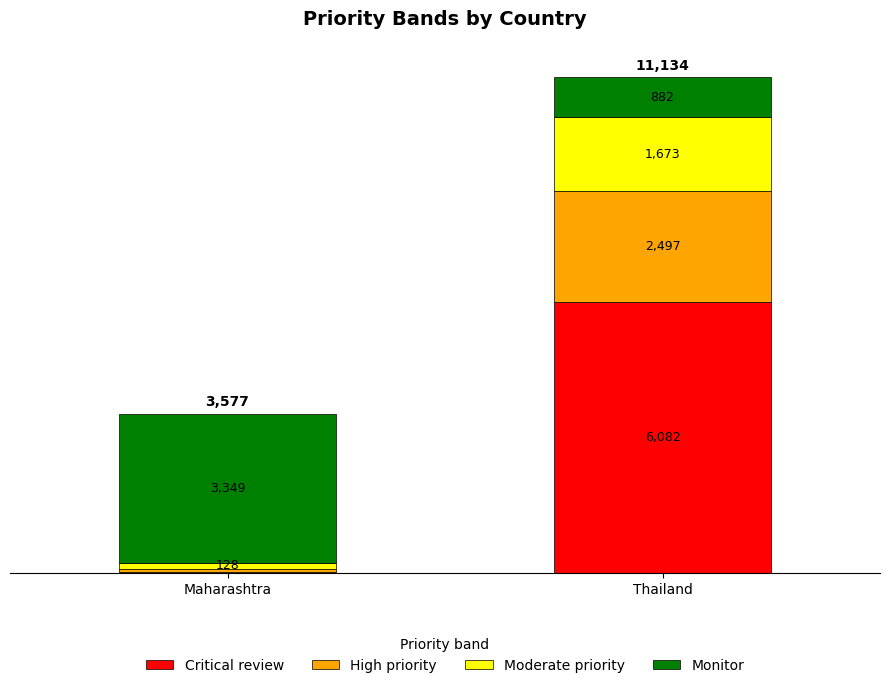

In [26]:
# Chart: priority bands by country
# Custom color mapping as requested
custom_colors = {
    "Critical review": "red",
    "High priority": "orange",
    "Moderate priority": "yellow",
    "Monitor": "green"
}

plot_counts = priority_counts.set_index("Country")[band_order]
ax = plot_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 7), # Increased height slightly to accommodate bottom legend
    color=[custom_colors.get(b, "gray") for b in band_order],
    edgecolor="black",
    linewidth=0.5
)

# Set title and remove labels per request
ax.set_title("Priority Bands by Country", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(plot_counts.index, rotation=0)

# Remove all spines and grid lines except for the baseline (y=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_ticks([]) # Remove y-axis ticks

# Add value labels per band with collision/clutter management
for container in ax.containers:
    labels = []
    for i, v in enumerate(container.datavalues):
        total_for_bar = plot_counts.iloc[i].sum()
        if v > 0 and (v / total_for_bar) > 0.03:
            labels.append(f"{v:,.0f}")
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

# Add total labels at the top of each bar
totals = plot_counts.sum(axis=1).values
for i, total in enumerate(totals):
    ax.text(i, total + (max(totals)*0.01), f'{total:,.0f}', ha='center', va='bottom', fontweight='bold')

# Move legend to bottom
ax.legend(
    title="Priority band",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_priority_bands_by_country.png", dpi=160, bbox_inches="tight")
plt.show()

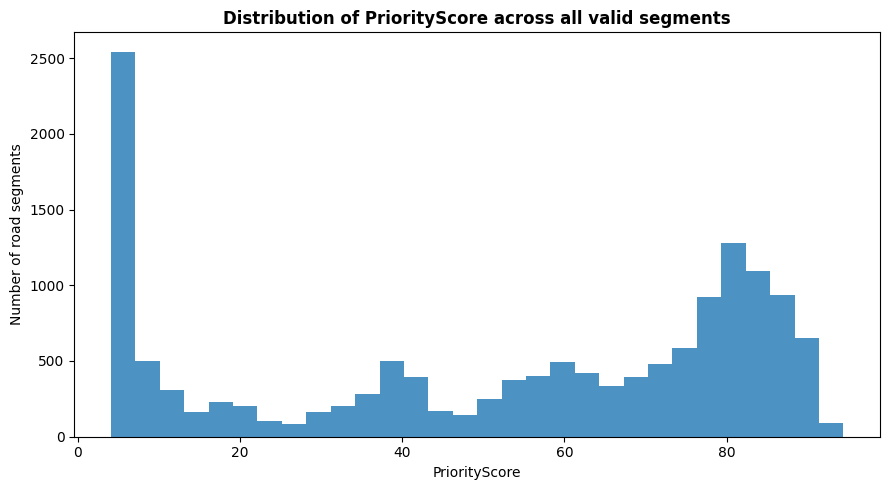

In [27]:
# Chart: priority score distribution
ax = valid["PriorityScore"].plot(kind="hist", bins=30, figsize=(9, 5), alpha=0.8)
ax.set_title("Distribution of PriorityScore across all valid segments", fontweight="bold")
ax.set_xlabel("PriorityScore")
ax.set_ylabel("Number of road segments")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_priority_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The PriorityScore distribution shows a two-sided pattern. A large number of segments fall in the low-score range, indicating roads that mainly require routine monitoring. At the same time, there is a clear concentration of high-scoring segments around the upper end of the distribution, suggesting that the model identifies a substantial group of roads for more urgent review. This supports the usefulness of the scoring framework because it separates segments into different priority levels rather than assigning similar scores to all roads. The results should be interpreted as a prioritization tool for review, not as a final safety judgment.

In [ ]:
# Top combinations by priority band: useful to understand where the strongest pattern comes from.
pattern_table = (
    valid.groupby(["Country", "LandUse", "RoadClass", "PriorityBand"])
    .agg(Segments=("SegmentID", "count"), Length_km=("Length_km", "sum"), MedianPriority=("PriorityScore", "median"))
    .reset_index()
)
pattern_table["Length_km"] = pattern_table["Length_km"].round(0).astype(int)
pattern_table["MedianPriority"] = pattern_table["MedianPriority"].round(1)
pattern_table.sort_values(["Country", "Segments"], ascending=[True, False]).head(20)

,Country,LandUse,RoadClass,PriorityBand,Segments,Length_km,MedianPriority
3,Maharashtra,RURAL,secondary,Monitor,1190,11198,6.9
4,Maharashtra,RURAL,trunk,Monitor,877,15697,4.4
2,Maharashtra,RURAL,primary,Monitor,743,11626,5.9
8,Maharashtra,URBAN,primary,Monitor,305,614,11.1
15,Maharashtra,URBAN,trunk,Monitor,197,561,9.6
10,Maharashtra,URBAN,secondary,Moderate priority,120,196,38.8
9,Maharashtra,URBAN,secondary,High priority,46,97,63.0
5,Maharashtra,URBAN,motorway,Monitor,23,51,8.4
13,Maharashtra,URBAN,trunk,High priority,21,66,59.6
7,Maharashtra,URBAN,primary,High priority,16,47,63.6


## 11. Top-priority segments and why they were flagged

This table is designed to be used directly in a submission or policy discussion. It shows not just which roads rank highest, but **why** they rank highly.

In [28]:
# ============================================================
# 11. Top segments with explainable component contributions
# ============================================================

top_columns = [
    "Country", "SegmentID", "RoadName", "RoadClass", "LandUse", "SpeedLimit", "SafeReferenceLimit_kmh",
    "F85thPercentileSpeed", "PostedExcess_kmh", "OperatingExcess_kmh",
    "PostedExcessContribution", "OperatingExcessContribution", "VRUContribution", "TrafficContribution", "PeerGapContribution",
    "PriorityScore", "SpeedSafetyScore", "PriorityBand", "Recommendation", "StreetImageLink"
]

top_25 = valid.sort_values("PriorityScore", ascending=False)[top_columns].head(25).copy()

for c in [
    "F85thPercentileSpeed", "PostedExcess_kmh", "OperatingExcess_kmh",
    "PostedExcessContribution", "OperatingExcessContribution", "VRUContribution", "TrafficContribution", "PeerGapContribution",
    "PriorityScore", "SpeedSafetyScore"
]:
    top_25[c] = top_25[c].round(1)

top_25

,Country,SegmentID,RoadName,RoadClass,LandUse,SpeedLimit,SafeReferenceLimit_kmh,F85thPercentileSpeed,PostedExcess_kmh,OperatingExcess_kmh,PostedExcessContribution,OperatingExcessContribution,VRUContribution,TrafficContribution,PeerGapContribution,PriorityScore,SpeedSafetyScore,PriorityBand,Recommendation,StreetImageLink
14185,Thailand,Thailand_104,Kanchanaphisek Road,trunk,URBAN,120.0,50,86.4,70.0,36.4,45.0,20.0,9.4,15.0,5.0,94.4,5.6,Critical review,Immediate engineering review and field validation,"100.4107064,13.6417155,100.43193453,13.96699621"
48122,Thailand,Thailand_34041,Phraek Sa Road,secondary,URBAN,90.0,30,65.5,60.0,35.5,45.0,20.0,12.0,14.5,2.6,94.1,5.9,Critical review,Immediate engineering review and field validation,"100.6088384,13.5870537,100.6931267,13.561889"
49607,Thailand,Thailand_35526,7 Frontage Road,secondary,URBAN,90.0,30,73.0,60.0,43.0,45.0,20.0,12.0,14.4,2.6,94.0,6.0,Critical review,Immediate engineering review and field validation,"100.9798512,13.1174787,100.9901822,13.1695521"
49608,Thailand,Thailand_35527,7 Frontage Road,secondary,URBAN,90.0,30,73.5,60.0,43.5,45.0,20.0,12.0,14.2,2.6,93.9,6.1,Critical review,Immediate engineering review and field validation,"100.9936166,13.1702103,100.9854164,13.1266561"
49029,Thailand,Thailand_34948,Phahon Yothin Road,secondary,URBAN,90.0,30,72.5,60.0,42.5,45.0,20.0,12.0,14.7,2.2,93.9,6.1,Critical review,Immediate engineering review and field validation,"100.6414464,14.1924122,100.76665496,14.25554596"
49521,Thailand,Thailand_35440,Kanchanaphisek Road Outer Service Road,secondary,URBAN,90.0,30,69.5,60.0,39.5,45.0,20.0,12.0,14.0,2.7,93.7,6.3,Critical review,Immediate engineering review and field validation,"100.69614827,14.07532886,100.7080897,14.0089861"
29792,Thailand,Thailand_15711,Borommaratchachonnani Road (frontage),secondary,URBAN,90.0,30,74.5,60.0,44.5,45.0,20.0,12.0,14.2,2.4,93.7,6.3,Critical review,Immediate engineering review and field validation,"100.2472605,13.7835041,100.3248097,13.7877394"
14486,Thailand,Thailand_405,Chalermprakiat Ror 9,secondary,URBAN,90.0,30,76.0,60.0,46.0,45.0,20.0,12.0,13.6,3.0,93.6,6.4,Critical review,Immediate engineering review and field validation,"98.38654376,7.95027207,98.3752149,7.9320134"
69843,Thailand,Thailand_55762,Bang Kruai-Sai Noi Road,secondary,URBAN,90.0,30,61.5,60.0,31.5,45.0,20.0,12.0,14.5,2.1,93.6,6.4,Critical review,Immediate engineering review and field validation,"100.32498932,13.98124145,100.4106348,13.9269943"
49516,Thailand,Thailand_35435,Kanchanaphisek Road Outer Service Road,secondary,URBAN,90.0,30,83.8,60.0,53.8,45.0,20.0,12.0,14.6,2.1,93.6,6.4,Critical review,Immediate engineering review and field validation,"100.6912026,13.896726,100.6752938,13.8554855"


### Interpretation of the top-priority list
A segment is usually high priority when several things happen together:

1. The posted limit is much higher than the Safe System reference speed.
2. The road is urban or otherwise likely to have vulnerable-road-user exposure.
3. The 85th percentile speed is also high relative to the reference.
4. The road has meaningful travel exposure.

This makes the output more useful than a simple “highest speed limit” list because it links speed limits to **road context and public-safety relevance**.

## 12. Sensitivity check: are the rankings stable?

A winning submission should show that the method is not overly fragile. Here we test two alternative weighting scenarios:

1. **Safety-heavy scenario:** gives more weight to posted-limit mismatch and VRU exposure.
2. **Exposure-heavy scenario:** gives more weight to traffic exposure.

We compare each scenario with the baseline using rank correlation and overlap in the top 300 priority segments.

In [29]:
# ============================================================
# 12. Sensitivity analysis
# ============================================================

def compute_priority_with_weights(df, weights):
    return 100 * (
        weights["posted"] * df["PostedExcessScore"] +
        weights["operating"] * df["OperatingExcessScore"] +
        weights["vru"] * df["VRUExposureProxy"] +
        weights["traffic"] * df["TrafficExposureScore"] +
        weights["peer"] * df["PeerGapScore"]
    )

weight_sets = {
    "Baseline": {"posted": 0.45, "operating": 0.20, "vru": 0.15, "traffic": 0.15, "peer": 0.05},
    "Safety-heavy": {"posted": 0.50, "operating": 0.20, "vru": 0.20, "traffic": 0.05, "peer": 0.05},
    "Exposure-heavy": {"posted": 0.40, "operating": 0.20, "vru": 0.15, "traffic": 0.20, "peer": 0.05},
}

sensitivity_scores = pd.DataFrame(index=valid.index)
for name, weights in weight_sets.items():
    sensitivity_scores[name] = compute_priority_with_weights(valid, weights)

baseline_top300 = set(valid.sort_values("PriorityScore", ascending=False).head(300)["SegmentID"])

sensitivity_results = []
for name in ["Safety-heavy", "Exposure-heavy"]:
    temp = valid[["SegmentID"]].copy()
    temp["ScenarioScore"] = sensitivity_scores[name]
    scenario_top300 = set(temp.sort_values("ScenarioScore", ascending=False).head(300)["SegmentID"])
    overlap = len(baseline_top300.intersection(scenario_top300))
    rank_corr = sensitivity_scores["Baseline"].corr(sensitivity_scores[name], method="spearman")
    sensitivity_results.append({
        "Scenario": name,
        "Spearman rank correlation vs baseline": round(rank_corr, 3),
        "Top 300 overlap count": overlap,
        "Top 300 overlap %": round(overlap / 300 * 100, 1)
    })

sensitivity_results = pd.DataFrame(sensitivity_results)
sensitivity_results

,Scenario,Spearman rank correlation vs baseline,Top 300 overlap count,Top 300 overlap %
0,Safety-heavy,0.985,191,63.7
1,Exposure-heavy,0.998,269,89.7


## 1. What this sensitivity analysis does

This section checks whether the final PriorityScore ranking is stable when the weights are slightly changed. In simple terms, it asks:

“If we change the importance of the scoring components, do we still mostly flag the same road segments?”

This is important because the PriorityScore is built from several signals: posted speed excess, operating speed excess, vulnerable road user exposure, traffic exposure, and peer gap. Since the weights are partly based on project judgment, we need to test whether the results are too sensitive to those choices.

The baseline weighting is:

*Signal	Baseline weight*
Posted speed excess	45%
Operating speed excess	20%
VRU exposure	15%
Traffic exposure	15%
Peer gap	5%

So the baseline score gives the most importance to posted speed-limit misalignment, then operating speed, then exposure signals, with peer comparison kept small.

## 2. What the two scenarios mean

The code tests two alternative scenarios:

Safety-heavy scenario
Signal	Weight
Posted speed excess	50%
Operating speed excess	20%
VRU exposure	20%
Traffic exposure	5%
Peer gap	5%

This version puts more emphasis on Safe System safety logic, especially posted speed excess and vulnerable road user exposure. It reduces the traffic exposure weight. In simple terms, this scenario asks:

“What if we care more about speed mismatch and vulnerable road users than road exposure?”

Exposure-heavy scenario
Signal	Weight
Posted speed excess	40%
Operating speed excess	20%
VRU exposure	15%
Traffic exposure	20%
Peer gap	5%

This version gives more weight to traffic exposure, meaning roads with greater travel exposure become more important. In simple terms, this scenario asks:

“What if we prioritize roads where more travel or road-user exposure occurs?”

## 3. How the comparison is measured

The code compares each scenario against the baseline in two ways.

First, it uses Spearman rank correlation. This checks whether the overall ranking of road segments stays similar. A value close to 1.0 means the ranking is almost the same as the baseline. A lower value would mean the ranking changed a lot.

Second, it checks the Top 300 overlap. This looks at the 300 highest-priority road segments under the baseline and asks:

“How many of those same 300 road segments are still in the top 300 under the new scenario?”

This is very practical because decision-makers will usually focus on the top priority list, not every single road in the dataset.

## 4. Safety-heavy result

The Safety-heavy scenario has a Spearman rank correlation of 0.985 versus the baseline. That is very high, which means the overall ranking remains almost the same even after increasing the weight of posted speed excess and VRU exposure.

However, the Top 300 overlap is 191 out of 300, or 63.7%. This means that around two-thirds of the baseline’s top 300 road segments are still selected, but about one-third changed.

This makes sense because the Safety-heavy version reduces traffic exposure and gives more importance to road safety mismatch and vulnerable road users. So some roads that were high-priority mainly because of exposure may move down, while roads with stronger Safe System concerns may move up.

## 5. Exposure-heavy result

The Exposure-heavy scenario has a Spearman rank correlation of 0.998 versus the baseline. This is extremely close to 1, so the ranking is almost identical to the baseline.

The Top 300 overlap is 269 out of 300, or 89.7%. This means almost 90% of the top 300 road segments under the baseline are still in the top 300 under the Exposure-heavy scenario.

This suggests that increasing the traffic exposure weight slightly does not drastically change the priority list. The baseline already included traffic exposure at 15%, so raising it to 20% keeps the results mostly consistent.

## 6. Overall interpretation and key takeaway

Overall, the sensitivity analysis shows that the scoring system is reasonably robust. The rankings do not collapse or completely change when the weights are adjusted. Both scenarios have very high Spearman correlations, meaning the overall road-segment ordering remains mostly consistent.

The main difference is in the Top 300 list. The Exposure-heavy scenario keeps almost the same top review list as the baseline, with 89.7% overlap. The Safety-heavy scenario changes the top list more, with 63.7% overlap, because it shifts priority toward roads with stronger Safe System and vulnerable-user concerns.




## 13. Geospatial outputs and interactive map

The challenge asks for spatial/map-based outputs. This section exports:

1. Full scored CSV
2. Full scored GeoJSON
3. Top 300 priority CSV
4. Summary by country
5. Priority crosstab
6. Peer-model diagnostics
7. Interactive HTML map of the top priority road segments

The map is saved as an HTML file instead of embedded directly in the notebook to keep the notebook lightweight and easy to submit.

In [30]:
# ============================================================
# 13. Save tabular and geospatial outputs
# ============================================================

# Carefully choose submission columns so outputs are useful but not unnecessarily cluttered.
submission_columns = [
    "Country", "SegmentID", "SourceRoadID", "OBJECTID", "RoadName", "RoadClass", "LandUse",
    "SpeedLimit", "SafeReferenceLimit_kmh", "MedianSpeed", "F85thPercentileSpeed", "F85MinusLimit_kmh",
    "PostedExcess_kmh", "OperatingExcess_kmh", "PercentOverLimit", "WeightedSample", "SampleSizeUnified",
    "RankedPercentile", "TrafficExposureScore", "VRUExposureProxy", "SampleConfidence",
    "PeerPredictedLimit_kmh", "PeerGap_kmh", "PostedExcessContribution", "OperatingExcessContribution",
    "VRUContribution", "TrafficContribution", "PeerGapContribution", "PriorityScore", "SpeedSafetyScore",
    "PriorityBand", "Recommendation", "StreetImageLink", "Shape_Length", "Length_km", "geometry"
]

# Ensure all output columns exist.
submission_columns = [c for c in submission_columns if c in valid.columns]
scored = valid[submission_columns].copy()

# Round selected values for readable outputs.
round_cols = [
    "MedianSpeed", "F85thPercentileSpeed", "F85MinusLimit_kmh", "PostedExcess_kmh", "OperatingExcess_kmh",
    "PercentOverLimit", "TrafficExposureScore", "VRUExposureProxy", "SampleConfidence", "PeerPredictedLimit_kmh",
    "PeerGap_kmh", "PostedExcessContribution", "OperatingExcessContribution", "VRUContribution",
    "TrafficContribution", "PeerGapContribution", "PriorityScore", "SpeedSafetyScore", "Length_km"
]
for c in round_cols:
    if c in scored.columns:
        scored[c] = scored[c].round(3)


scored_csv = OUTPUT_DIR / "speed_safety_scored_segments.csv"
# Full GeoJSON of all scored segments can be large and slow to write in some notebook environments.
# We therefore export a lightweight top-priority GeoJSON by default and keep the full GeoJSON as optional.
SAVE_FULL_GEOJSON = False
scored_geojson = OUTPUT_DIR / "speed_safety_scored_segments.geojson"
top300_csv = OUTPUT_DIR / "top_300_priority_segments.csv"
top300_geojson = OUTPUT_DIR / "top_300_priority_segments.geojson"
summary_csv = OUTPUT_DIR / "model_summary_by_country.csv"
priority_counts_csv = OUTPUT_DIR / "priority_crosstab_counts.csv"
priority_lengths_csv = OUTPUT_DIR / "priority_crosstab_length_km.csv"
peer_metrics_csv = OUTPUT_DIR / "peer_model_metrics.csv"
filter_funnel_csv = OUTPUT_DIR / "filter_funnel.csv"
sensitivity_csv = OUTPUT_DIR / "sensitivity_check.csv"

# Save full CSV without geometry. This is the main all-segment analytical output.
scored.drop(columns="geometry", errors="ignore").to_csv(scored_csv, index=False)

# Save top 300 CSV and top 300 GeoJSON for immediate GIS/map review.
top300 = scored.sort_values("PriorityScore", ascending=False).head(300).copy()
top300.drop(columns="geometry", errors="ignore").to_csv(top300_csv, index=False)
top300_geo = gpd.GeoDataFrame(top300, geometry="geometry", crs=valid.crs)
top300_geojson.write_text(top300_geo.to_json(), encoding="utf-8")

# Optional: set SAVE_FULL_GEOJSON = True if a full GIS layer of all scored valid segments are needed.
# This may take several minutes depending on the environment.
if SAVE_FULL_GEOJSON:
    scored_geo = gpd.GeoDataFrame(scored, geometry="geometry", crs=valid.crs)
    scored_geojson.write_text(scored_geo.to_json(), encoding="utf-8")

summary_by_country.to_csv(summary_csv, index=False)
priority_counts.to_csv(priority_counts_csv, index=False)
priority_lengths_rounded.to_csv(priority_lengths_csv, index=False)
peer_metrics.to_csv(peer_metrics_csv, index=False)
filter_funnel.to_csv(filter_funnel_csv, index=False)
sensitivity_results.to_csv(sensitivity_csv, index=False)

created_outputs = pd.DataFrame({
    "Output file": [
        scored_csv.name, top300_geojson.name, top300_csv.name, summary_csv.name, priority_counts_csv.name,
        priority_lengths_csv.name, peer_metrics_csv.name, filter_funnel_csv.name, sensitivity_csv.name
    ],
    "Purpose": [
        "Full scored model output for every valid road segment",
        "GIS-ready top-priority road layer for immediate map review",
        "Immediate review list for policy and engineering teams",
        "Country-level summary",
        "Priority-band counts by country",
        "Priority-band length by country",
        "AI peer-model diagnostics",
        "Data validation and filtering audit",
        "Weight sensitivity and ranking stability check"
    ]
})
created_outputs

,Output file,Purpose
0,speed_safety_scored_segments.csv,Full scored model output for every valid road segment
1,top_300_priority_segments.geojson,GIS-ready top-priority road layer for immediate map review
2,top_300_priority_segments.csv,Immediate review list for policy and engineering teams
3,model_summary_by_country.csv,Country-level summary
4,priority_crosstab_counts.csv,Priority-band counts by country
5,priority_crosstab_length_km.csv,Priority-band length by country
6,peer_model_metrics.csv,AI peer-model diagnostics
7,filter_funnel.csv,Data validation and filtering audit
8,sensitivity_check.csv,Weight sensitivity and ranking stability check


In [31]:
# ============================================================
# 13.2 Create an interactive map of all segments with filters
# ============================================================

import folium
from folium import plugins
from shapely.geometry import LineString, MultiLineString

# Prepare the full dataset for mapping
map_gdf = scored.copy()
map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=valid.crs)

# Ensure CRS is EPSG:4326 for Folium
try:
    if map_gdf.crs is not None and map_gdf.crs.to_epsg() != 4326:
        map_gdf = map_gdf.to_crs(epsg=4326)
except Exception:
    pass

# Get top 300 IDs for the special layer
top_300_ids = set(map_gdf.sort_values("PriorityScore", ascending=False).head(300)["SegmentID"])

center = map_gdf.geometry.unary_union.centroid
# Initialize map without a default tile set to allow manual addition of light/dark options
m = folium.Map(location=[center.y, center.x], zoom_start=6, tiles=None)

# Add Light and Dark base layers
folium.TileLayer("CartoDB dark_matter", name="Dark Mode", control=True).add_to(m)
folium.TileLayer("CartoDB positron", name="Light Mode", control=True).add_to(m)

# Color mapping as requested
band_colors = {
    "Critical review": "red",
    "High priority": "orange",
    "Moderate priority": "yellow",
    "Monitor": "green"
}

# Create Feature Groups for filtering
groups = {
    "Monitor": folium.FeatureGroup(name="Monitor"),
    "Moderate priority": folium.FeatureGroup(name="Moderate priority"),
    "High priority": folium.FeatureGroup(name="High priority"),
    "Critical review": folium.FeatureGroup(name="Critical review"),
    "Top 300 Priority": folium.FeatureGroup(name="Top 300 Priority")
}

def iter_lines(geom):
    if geom is None or geom.is_empty: return []
    if isinstance(geom, LineString): return [geom]
    if isinstance(geom, MultiLineString): return list(geom.geoms)
    return []

for _, row in map_gdf.iterrows():
    band = row.get("PriorityBand", "Monitor")
    is_top_300 = row["SegmentID"] in top_300_ids
    color = band_colors.get(band, "gray")
    road_name = row.get('RoadName', 'Unnamed road')

    # Logic for conditional coloring of F85 speed
    f85 = row.get('F85thPercentileSpeed', 0)
    limit = row.get('SpeedLimit', 0)
    f85_color = "red" if f85 > limit else "green"

    # Details for detailed view (click)
    popup_html = f'''
    <div style="font-family: sans-serif; min-width: 200px;">
    <b>{road_name}</b><br>
    Band: {band}<br>
    Priority Score: {row.get('PriorityScore')}<br>
    Posted Speed Limit: {limit} km/h<br>
    85th Percentile Speed: <span style="color:{f85_color}; font-weight:bold;">{f85}</span> km/h<br>
    Reference Speed: {row.get('SafeReferenceLimit_kmh')} km/h<br>
    Country: {row.get('Country')}<br>
    Class: {row.get('RoadClass')}<br>
    Land Use: {row.get('LandUse')}
    </div>
    '''

    # Details for quick view (hover)
    tooltip_text = f'''
    <div style="font-family: sans-serif; min-width: 200px;">
    <b>{road_name}</b><br>
    Band: {band}<br>
    Priority Score: {row.get('PriorityScore')}<br>
    Posted Speed Limit: {limit} km/h<br>
    85th Percentile Speed: <span style="color:{f85_color}; font-weight:bold;">{f85}</span> km/h<br>
    Reference Speed: {row.get('SafeReferenceLimit_kmh')} km/h<br>
    Country: {row.get('Country')}<br>
    Class: {row.get('RoadClass')}<br>
    Land Use: {row.get('LandUse')}
    </div>
    '''

    lines = iter_lines(row.geometry)
    for line in lines:
        coords = [(lat, lon) for lon, lat in list(line.coords)]

        # Add to the standard Priority Band layer
        folium.PolyLine(coords, color=color, weight=1.5, opacity=0.6,
                        popup=folium.Popup(popup_html, max_width=350),
                        tooltip=folium.Tooltip(tooltip_text)).add_to(groups[band])

        # If it's in the top 300, add to the special purple layer
        if is_top_300:
            folium.PolyLine(coords, color="purple", weight=1.5, opacity=0.6,
                            popup=folium.Popup(f"<b>TOP 300</b><br>{popup_html}", max_width=350),
                            tooltip=folium.Tooltip(f"<b>TOP 300</b><br>{tooltip_text}")).add_to(groups["Top 300 Priority"])

# Add all groups to map and enable layer control at top left
for g in groups.values():
    g.add_to(m)

folium.LayerControl(position='topleft', collapsed=False).add_to(m)

# Update legend with purple and new colors
legend_html = '''
<div style="position: fixed; bottom: 20px; left: 20px; width: 160px; z-index:9999; background-color:white; border:0px solid grey; padding: 10px; font-size: 11px;">
<span style="color:green;">●</span> Monitor<br>
<span style="color:yellow;">●</span> Moderate priority<br>
<span style="color:orange;">●</span> High priority<br>
<span style="color:red;">●</span> Critical review<br>
<span style="color:purple;">●</span> Top 300 Priority
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

map_html = OUTPUT_DIR / "full_network_priority_map.html"
m.save(map_html)

print("Interactive map with all segments saved to:", map_html)
m

Output hidden; open in https://colab.research.google.com to view.

## 14. Key insights for the submission narrative

1. **The model solves the correct problem.** It evaluates whether posted speed limits appear aligned with Safe System principles and road context, rather than identifying individual speeding behavior.
2. **The results are actionable.** The output is not only a score; it gives a ranked list, priority band, recommendation, map layer, and interactive map.
3. **The method is scalable.** The same standardized field schema works across Maharashtra and Thailand, despite different original field names.
4. **The model is transparent.** Every road segment can be explained through component contributions.
5. **The AI/ML is used responsibly.** The peer model adds innovation but is weighted lightly because legal speed limits require engineering details beyond the available dataset.
6. **The model is designed for refinement.** In the next phase, it can absorb street-level imagery, school/market proximity, crash history, intersection density, medians/barriers, and pedestrian crossing data.

In [32]:
# Create a concise executive summary from the model outputs.
crit_high = valid[valid["PriorityBand"].isin(["Critical review", "High priority"])]
crit_high_summary = crit_high.groupby("Country").agg(
    Critical_High_Segments=("SegmentID", "count"),
    Critical_High_Length_km=("Length_km", "sum"),
    Median_Priority=("PriorityScore", "median")
).reset_index()
crit_high_summary["Critical_High_Length_km"] = crit_high_summary["Critical_High_Length_km"].round(0).astype(int)
crit_high_summary["Median_Priority"] = crit_high_summary["Median_Priority"].round(1)

print("Executive summary")
print("- Valid scored segments:", len(valid))
print("- Total scored length (km):", round(valid["Length_km"].sum(), 0))
print("- Critical/high segments:", len(crit_high))
print("- Critical/high length (km):", round(crit_high["Length_km"].sum(), 0))
print("\nCritical/high summary by country:")
display(crit_high_summary)

Executive summary
- Valid scored segments: 14711
- Total scored length (km): 99986.0
- Critical/high segments: 8679
- Critical/high length (km): 45349.0

Critical/high summary by country:


,Country,Critical_High_Segments,Critical_High_Length_km,Median_Priority
0,Maharashtra,100,267,64.6
1,Thailand,8579,45082,78.8


## 15. Recommended additions before final challenge submission

### Highest-impact additions
1. **Add Mapillary / street-level imagery features** if the challenge dataset provides usable image features or URLs. Examples: pedestrian crossing, median barrier, lane count, shoulder, roadside activity, signs.
2. **Add school, market, hospital, transit stop, and population-density layers** to improve the vulnerable-road-user exposure proxy.
3. **Add crash history** if available, especially fatal and serious injury crashes, to validate whether flagged roads align with observed harm.
4. **Add intersection density and access-control indicators** to better distinguish urban arterials from protected motorways.
5. **Add a reviewer-facing dashboard or map story** showing top segments, why they were flagged, and what intervention type may be appropriate.

### Potential intervention tags for the next version
The model can later recommend possible intervention categories such as:
- speed-limit review,
- traffic calming,
- pedestrian crossing review,
- median/barrier assessment,
- school/market-zone treatment,
- enforcement support only after engineering review.

## 16. Final submission positioning

> We developed a reproducible AI/ML and geospatial screening model that identifies road segments where posted speed limits may be misaligned with Safe System principles, road function, land use, observed operating speeds, vulnerable-road-user exposure, and travel exposure. The model produces a Speed Safety Score, Priority Score, priority band, recommendation, GIS layer, and interactive map. It is designed to help governments prioritize engineering review and field validation, not to automatically change legal speed limits or blame individual drivers.

The main strength of the approach is that it is **transparent enough for policy users**, **reproducible enough for technical reviewers**, and **scalable enough to apply across countries** with similar mobility and road-network datasets.

In [33]:
# ============================================================
# 16. Final check: list all created files
# ============================================================

all_outputs = sorted([p for p in OUTPUT_DIR.glob("*") if p.is_file()])
pd.DataFrame({"Created file": [p.name for p in all_outputs], "Size MB": [round(p.stat().st_size / 1_000_000, 3) for p in all_outputs]})

,Created file,Size MB
0,01_filtering_funnel.png,0.076
1,02a_speedlimit_vs_f85_by_country.png,0.212
2,02b_speedlimit_vs_f85_combined.png,0.251
3,03_priority_bands_by_country.png,0.041
4,04_priority_score_distribution.png,0.041
5,filter_funnel.csv,0.000
6,full_network_priority_map.html,83.489
7,model_summary_by_country.csv,0.000
8,peer_model_metrics.csv,0.000
9,priority_crosstab_counts.csv,0.000
